# Plan to serve 10 trillion tokens and Chinchilla's 70B becomes 30B

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Anchoring the fit at 70B / 1.4T

In [1]:
import numpy as np

E, A, alpha, beta = 1.69, 406.4, 0.34, 0.28
N0, D0 = 70e9, 1.4e12                     # Chinchilla's own operating point
B = alpha * A * N0**-alpha / (beta * D0**-beta)   # calibrate B to the anchor

def loss(N, D, A=A, B=B, a=alpha, b=beta):
    return E + A * N**-a + B * D**-b

def closed_form(C, A=A, B=B, a=alpha, b=beta):
    N = (a * A / (b * B))**(1 / (a + b)) * (C / 6)**(b / (a + b))
    return N, C / (6 * N)

print(f"calibrated B = {B:.1f}")
N_grid = np.logspace(8, 13, 500_001)       # 1e8 .. 1e13 parameters
for C in (1e21, 1e23, 5.88e23, 1e25):
    D_grid = C / (6 * N_grid)              # every point spends exactly C
    i = np.argmin(loss(N_grid, D_grid))
    Nc, Dc = closed_form(C)
    print(f"C={C:.2e}  grid N={N_grid[i]/1e9:6.1f}B D={D_grid[i]/1e9:6.0f}B "
          f"D/N={D_grid[i]/N_grid[i]:5.1f} | closed N={Nc/1e9:6.1f}B D/N={Dc/Nc:5.1f}")

C = 5.88e23                                # same budget, other constants
for name, a, b, BB in (("paper, rounded exps ", 0.34, 0.28, 410.7),
                       ("paper, 4-digit exps ", 0.3392, 0.2849, 410.7)):
    N, D = closed_form(C, A, BB, a, b)
    print(f"{name} N={N/1e9:5.1f}B D={D/1e12:4.2f}T D/N={D/N:5.1f}  b/(a+b)={b/(a+b):.4f}"
          f"  prefactor {(a*A/(b*BB))**(1/(a+b)):.3f}  (C/6)^(b/(a+b)) {(C/6)**(b/(a+b))/1e9:.1f}B")
print(f"ln(C/6) = {np.log(C / 6):.1f}, drift exponent (a-b)/(a+b) = {(alpha-beta)/(alpha+beta):.3f}")

calibrated B = 255.2
C=1.00e+21  grid N=   3.9B D=    42B D/N= 10.8 | closed N=   3.9B D/N= 10.8
C=1.00e+23  grid N=  31.5B D=   530B D/N= 16.8 | closed N=  31.5B D/N= 16.8
C=5.88e+23  grid N=  70.0B D=  1400B D/N= 20.0 | closed N=  70.0B D/N= 20.0
C=1.00e+25  grid N= 251.7B D=  6622B D/N= 26.3 | closed N= 251.7B D/N= 26.3
paper, rounded exps  N= 32.5B D=3.02T D/N= 92.8  b/(a+b)=0.4516  prefactor 1.345  (C/6)^(b/(a+b)) 24.2B
paper, 4-digit exps  N= 40.7B D=2.41T D/N= 59.2  b/(a+b)=0.4565  prefactor 1.300  (C/6)^(b/(a+b)) 31.3B
ln(C/6) = 52.9, drift exponent (a-b)/(a+b) = 0.097


## Serving pulls the optimum smaller

In [2]:
L_star = loss(N0, D0)                      # loss of the 70B / 1.4T model
D_inf = 1e13                               # tokens served over its lifetime
print(f"target loss {L_star:.4f}, serving {D_inf:.0e} tokens")
for N in (70e9, 50e9, 40e9, 30e9, 25e9):
    D = (B / (L_star - E - A * N**-alpha))**(1 / beta)   # tokens for same loss
    train, serve = 6 * N * D, 2 * N * D_inf
    print(f"N={N/1e9:3.0f}B D={D/1e12:5.2f}T D/N={D/N:4.0f} "
          f"train {train:.2e} serve {serve:.2e} total {train+serve:.2e}")

for D_inf in (0, 1e12, 1e13):              # fix the TOTAL at 5.88e23 instead
    D = (5.88e23 - 2 * N_grid * D_inf) / (6 * N_grid)
    L = np.where(D > 0, loss(N_grid, np.maximum(D, 1.0)), np.inf)
    i = np.argmin(L)
    print(f"total budget, D_inf={D_inf:.0e}: N={N_grid[i]/1e9:4.1f}B "
          f"D={D[i]/1e12:4.2f}T D/N={D[i]/N_grid[i]:4.0f} loss {L[i]:.4f}")

N, D = 8e9, 15e12                          # Llama-3-8B on 15T tokens
ratio = alpha * A * N**-alpha / (beta * B * D**-beta)    # = 1 + D_inf / 3D
print(f"Llama-3-8B: ratio {ratio:.2f}, implied D_inf = 3D(ratio-1) = {3*D*(ratio-1)/1e12:.0f}T "
      f"= {3*(ratio-1):.1f} x training tokens")

target loss 1.8749, serving 1e+13 tokens
N= 70B D= 1.40T D/N=  20 train 5.88e+23 serve 1.40e+24 total 1.99e+24
N= 50B D= 2.04T D/N=  41 train 6.11e+23 serve 1.00e+24 total 1.61e+24
N= 40B D= 2.75T D/N=  69 train 6.61e+23 serve 8.00e+23 total 1.46e+24
N= 30B D= 4.41T D/N= 147 train 7.94e+23 serve 6.00e+23 total 1.39e+24
N= 25B D= 6.35T D/N= 254 train 9.53e+23 serve 5.00e+23 total 1.45e+24
total budget, D_inf=0e+00: N=70.0B D=1.40T D/N=  20 loss 1.8749
total budget, D_inf=1e+12: N=48.3B D=1.69T D/N=  35 loss 1.8808
total budget, D_inf=1e+13: N=15.3B D=3.06T D/N= 200 loss 1.9114
Llama-3-8B: ratio 4.06, implied D_inf = 3D(ratio-1) = 138T = 9.2 x training tokens


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

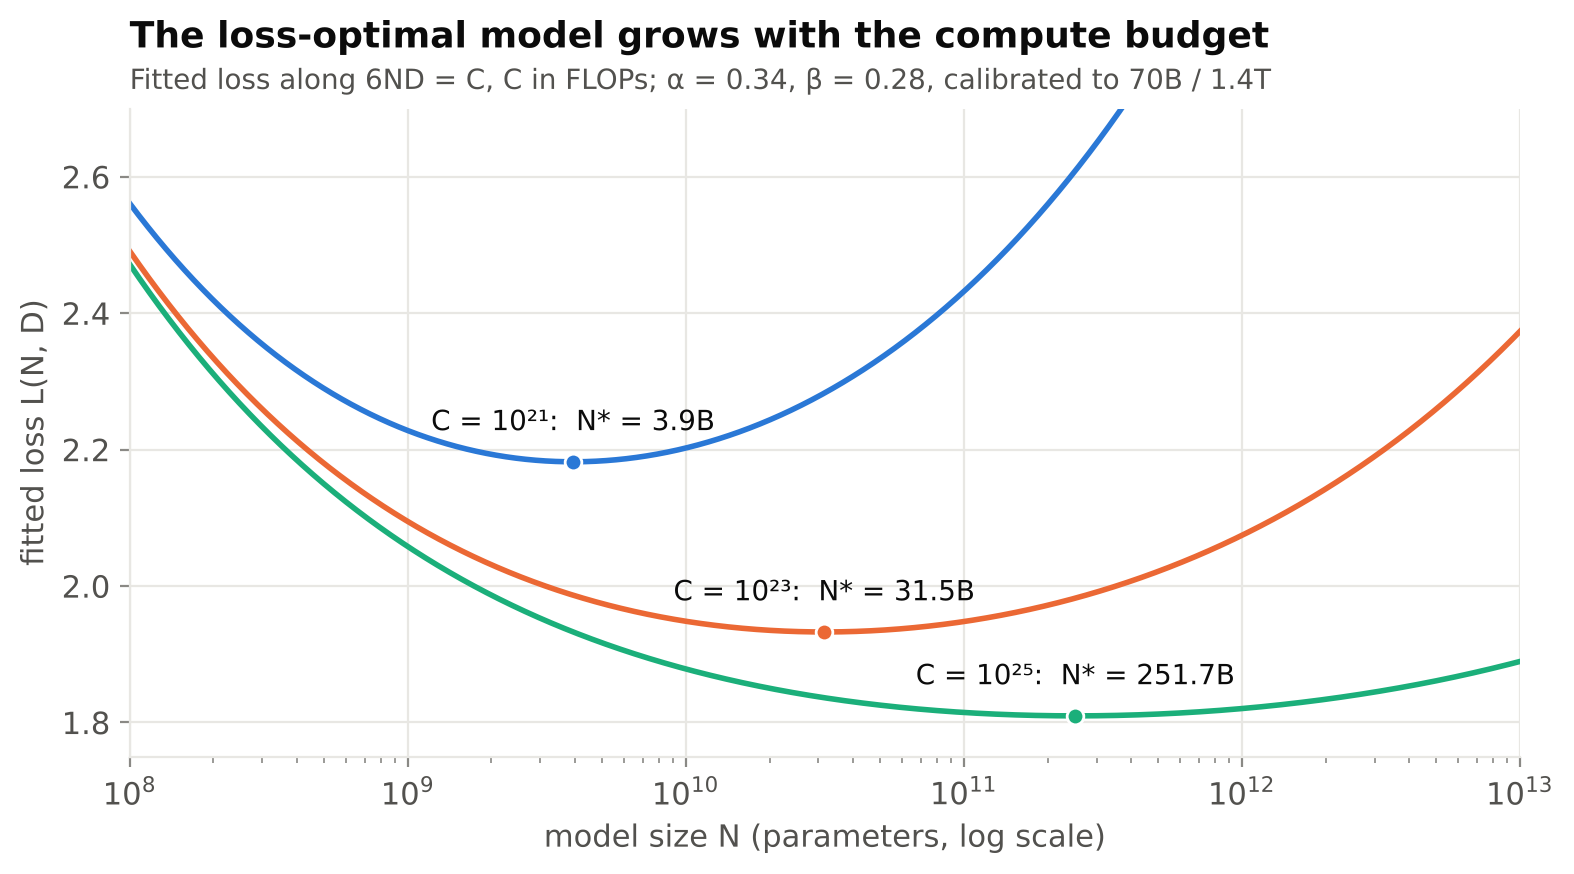

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # Constants and calibration from the article's first code block.
    E, A, alpha, beta = 1.69, 406.4, 0.34, 0.28
    N0, D0 = 70e9, 1.4e12
    B = alpha * A * N0**-alpha / (beta * D0**-beta)


    def loss(N, D):
        return E + A * N**-alpha + B * D**-beta


    N = np.logspace(8, 13, 500_001)
    f, ax = fig()
    for C, c, lab in ((1e21, S1, "10²¹"), (1e23, S2, "10²³"), (1e25, S3, "10²⁵")):
        L = loss(N, C / (6 * N))
        i = np.argmin(L)
        print(f"C={C:.0e}: N*={N[i]/1e9:.1f}B D/N={C/(6*N[i])/N[i]:.1f} L*={L[i]:.4f}")
        ax.plot(N, L, color=c, lw=2)
        ax.plot(N[i], L[i], "o", color=c, ms=6, zorder=3, mec="white", mew=1)
        ax.annotate(f"C = {lab}:  N* = {N[i]/1e9:.1f}B", (N[i], L[i]), xytext=(0, 9),
                    textcoords="offset points", ha="center", va="bottom", color=INK, fontsize=10)

    ax.set_xscale("log")
    ax.set_xlim(1e8, 1e13)
    ax.set_ylim(1.75, 2.7)
    ax.set_xlabel("model size N (parameters, log scale)")
    ax.set_ylabel("fitted loss L(N, D)")
    ax.set_title("The loss-optimal model grows with the compute budget")
    subtitle(ax, "Fitted loss along 6ND = C, C in FLOPs; α = 0.34, β = 0.28, calibrated to 70B / 1.4T")
    save(f, pathlib.Path(__file__).parent / "12-isoflop-curves.png")
import matplotlib.pyplot as plt
plt.show()